### 1. Introdução
A obesidade é uma condição médica caracterizada pelo acúmulo excessivo de gordura corporal, capaz de comprometer a saúde e aumentar o risco de diversas doenças crônicas. Trata-se de um problema de saúde pública global, que afeta pessoas de diferentes idades, perfis e contextos sociais. Suas causas são multifatoriais, envolvendo fatores genéticos, ambientais, comportamentais e de estilo de vida.

Diante disto, este projeto tem como objetivo investigar o potencial de modelos de Machine Learning na predição dos níveis de obesidade. A proposta central consiste em comparar dois cenários distintos:

1. modelos treinados exclusivamente com variáveis relacionadas a hábitos e comportamentos;
2. modelos que também incorporam medidas corporais, como peso e altura.

No primeiro cenário, busca-se compreender até que ponto fatores comportamentais — como frequência de atividade física, hábitos alimentares, consumo de água, uso de dispositivos eletrônicos e padrões de alimentação — são capazes de prever o nível de obesidade sem depender diretamente de características antropométricas. Esse enfoque é especialmente relevante por utilizar informações de fácil coleta em ambientes clínicos, escolares ou aplicações digitais de triagem.

No segundo cenário, são adicionadas variáveis corporais tradicionalmente associadas ao diagnóstico de obesidade, permitindo avaliar o impacto dessas informações na capacidade preditiva dos modelos. A comparação entre os dois contextos possibilita analisar não apenas o ganho de desempenho obtido com dados biométricos, mas também a viabilidade de modelos mais simples, acessíveis e menos invasivos.

### 2. Coleta de Dados
Utilizou-se, neste projeto, a base de dados *<u>obesity.csv</u>*, disponibilizada pelos professores responsáveis pelo desafio. O arquivo foi fornecido em formato CSV e contém informações relacionadas a medidas corporais, hábitos alimentares, rotina de atividade física, consumo de água, comportamento sedentário, histórico familiar e demais variáveis comportamentais associadas ao desenvolvimento da obesidade.

O conjunto de dados apresenta estrutura tabular e acompanha um dicionário de variáveis que descreve o significado de cada atributo, permitindo a correta interpretação dos registros e orientando as etapas de limpeza, tratamento e análise exploratória.

In [1]:
# ==================================================
# BIBLIOTECAS E CONFIGURAÇÕES
# ==================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
# ==================================================
# COLETA DE DADOS
# ==================================================
df_original = pd.read_csv(
    "C:/Users/diego/Desktop/obesity.csv",
    sep=","
)

### 3. Análise Exploratória dos Dados
Durante a etapa de análise exploratória, a base de dados foi carregada e inspecionada para compreensão da estrutura dos dados e das variáveis disponíveis. A partir desse arquivo CSV e de seu respectivo dicionário de dados, foi possível organizar o conjunto de dados, interpretar suas variáveis e preparar a base para as etapas seguintes de limpeza, análise e modelagem preditiva.

#### 3.1. Visão Geral dos Dados Brutos

In [3]:
# ==================================================
# VISÃO GERAL DOS DADOS BRUTOS
# ==================================================
print("Tipos de dados:")
print(df_original.dtypes)

print("\nShape:")
print(df_original.shape)

display(df_original.head())

Tipos de dados:
Gender             object
Age               float64
Height            float64
Weight            float64
family_history     object
FAVC               object
FCVC              float64
NCP               float64
CAEC               object
SMOKE              object
CH2O              float64
SCC                object
FAF               float64
TUE               float64
CALC               object
MTRANS             object
Obesity            object
dtype: object

Shape:
(2111, 17)


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


#### 3.2. Dicionário de dados
- **Gender** – *(Gênero)* Sexo biológico.  
  **Valores:** `Female`, `Male`.

- **Age** – *(Idade)* Idade em anos.  
  **Valores:** numérico contínuo *(mín 14, máx 61)*.

- **Height** – *(Altura)* Altura em metros.  
  **Valores:** numérico contínuo *(ex.: 1.45–1.98 m)*.

- **Weight** – *(Peso)* Peso em quilogramas.  
  **Valores:** numérico contínuo *(ex.: 39–173 kg)*.

- **family_history** – *(Family history of overweight)* Histórico familiar de excesso de peso.  
  **Valores:** `yes` (há histórico), `no` (não há).

- **FAVC** – *(Frequent consumption of high-caloric food)* Consumo frequente de alimentos muito calóricos.  
  **Valores:** `yes` (sim), `no` (não).

- **FCVC** – *(Frequency of consumption of vegetables)* Frequência de consumo de vegetais nas refeições.  
  **Valores (escala 1–3):**
  - `1` raramente  
  - `2` às vezes  
  - `3` sempre  

  *Nota:* no arquivo os valores aparecem com decimais (ruído); interprete arredondando para o inteiro mais próximo.

- **NCP** – *(Number of main meals)* Número de refeições principais por dia.  
  **Valores (escala 1–4):**
  - `1` uma refeição  
  - `2` duas  
  - `3` três  
  - `4` quatro ou mais  

  *Nota:* valores decimais devem ser arredondados.

- **CAEC** – *(Consumption of food between meals)* Consumo de lanches/comes entre as refeições.  
  **Valores:**  
  - `no` (não consome)  
  - `Sometimes` (às vezes)  
  - `Frequently` (frequentemente)  
  - `Always` (sempre)

- **SMOKE** – *(Smoking)* Hábito de fumar.  
  **Valores:** `yes` (fuma), `no` (não fuma).

- **CH2O** – *(Daily water consumption)* Consumo diário de água.  
  **Valores (escala 1–3):**
  - `1` < 1 L/dia  
  - `2` 1–2 L/dia  
  - `3` > 2 L/dia  

  *Nota:* arredonde valores decimais para interpretar a categoria.

- **SCC** – *(Calories consumption monitoring)* Monitora a ingestão calórica diária.  
  **Valores:** `yes` (sim), `no` (não).

- **FAF** – *(Physical activity frequency)* Frequência semanal de atividade física.  
  **Valores (escala 0–3):**
  - `0` nenhuma  
  - `1` ~1–2x/sem  
  - `2` ~3–4x/sem  
  - `3` 5x/sem ou mais  

  *Nota:* arredonde valores decimais.

- **TUE** – *(Time using electronic devices)* Tempo diário usando dispositivos eletrônicos.  
  **Valores (escala 0–2):**
  - `0` ~0–2 h/dia  
  - `1` ~3–5 h/dia  
  - `2` > 5 h/dia  

  *Nota:* arredonde valores decimais.

- **CALC** – *(Alcohol consumption)* Consumo de bebida alcoólica.  
  **Valores:**  
  - `no` (não bebe)  
  - `Sometimes` (às vezes)  
  - `Frequently` (frequentemente)  
  - `Always` (sempre)

- **MTRANS** – *(Transportation used / Mode of transport)* Meio de transporte habitual.  
  **Valores:**  
  - `Automobile` (carro)  
  - `Motorbike` (moto)  
  - `Bike` (bicicleta)  
  - `Public_Transportation` (transporte público)  
  - `Walking` (a pé)

- **Obesity** – *(Target label / Nível de obesidade)* Classe de peso corporal.  
  **Valores:**  
  - `Insufficient_Weight` (abaixo do peso)  
  - `Normal_Weight` (peso normal)  
  - `Overweight_Level_I` (sobrepeso I)  
  - `Overweight_Level_II` (sobrepeso II)  
  - `Obesity_Type_I` (obesidade I)  
  - `Obesity_Type_II` (obesidade II)  
  - `Obesity_Type_III` (obesidade III)

#### 3.3. Tratamento dos Dados

In [4]:
# ==================================================
# ARREDONDAMENTO DE VARIÁVEIS NUMÉRICAS
# ==================================================
df = df_original.copy()

colunas_arredondadas = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

df[colunas_arredondadas] = (
    df[colunas_arredondadas]
    .round()
    .astype(int)
)

#### 3.4. Visão Geral dos Dados Tratados

In [5]:
# ==================================================
# VISÃO GERAL DOS DADOS TRATADOS
# ==================================================
print("Tipos de dados:")
print(df.dtypes)

display(df.head())

Tipos de dados:
Gender             object
Age               float64
Height            float64
Weight            float64
family_history     object
FAVC               object
FCVC                int64
NCP                 int64
CAEC               object
SMOKE              object
CH2O                int64
SCC                object
FAF                 int64
TUE                 int64
CALC               object
MTRANS             object
Obesity            object
dtype: object


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II


#### 3.5. Estatística Descritiva

In [6]:
# ==================================================
# ESTATÍSTICA DESCRITIVA
# ==================================================
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.423496,2.687826,2.014685,1.006632,0.664614
std,6.345968,0.093305,26.191172,0.583905,0.809680,0.688616,0.895462,0.674009
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,3.000000,2.000000,0.000000,0.000000
50%,22.777890,1.700499,83.000000,2.000000,3.000000,2.000000,1.000000,1.000000
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.000000,2.000000,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


#### 3.6. Distribuição das Variáveis
A análise da distribuição das variáveis permite identificar padrões, assimetrias, categorias dominantes e possíveis problemas de variabilidade que podem impactar diretamente o desempenho dos modelos de machine learning.

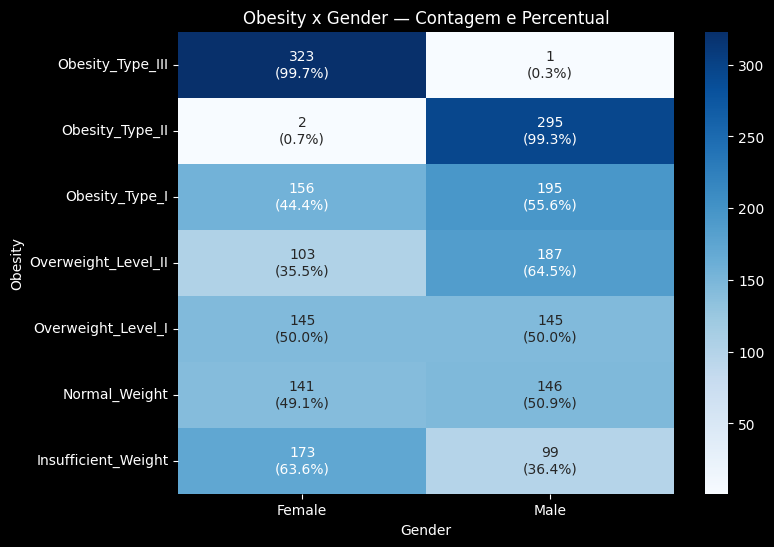

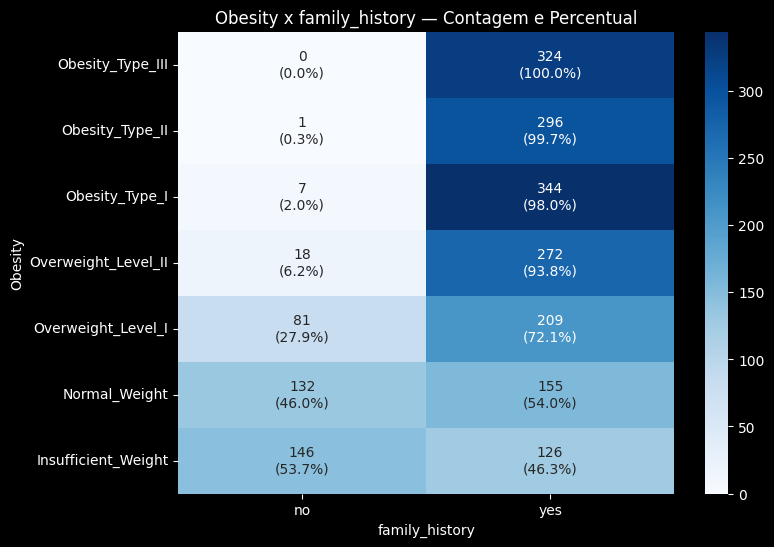

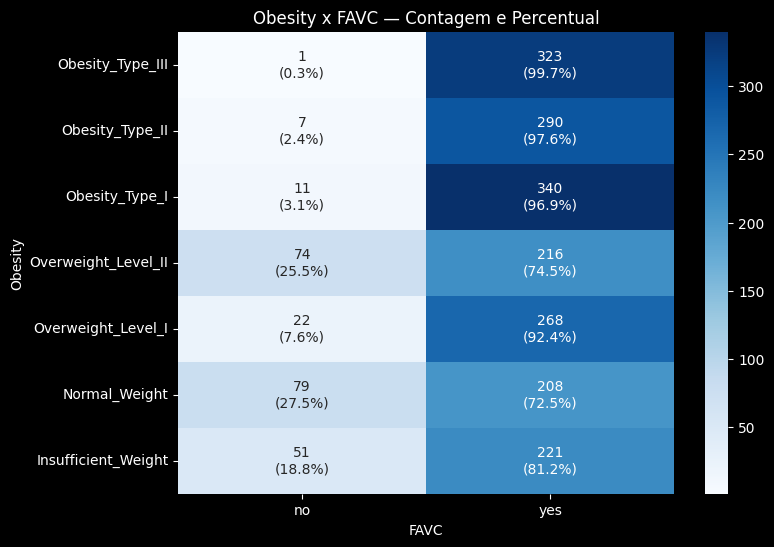

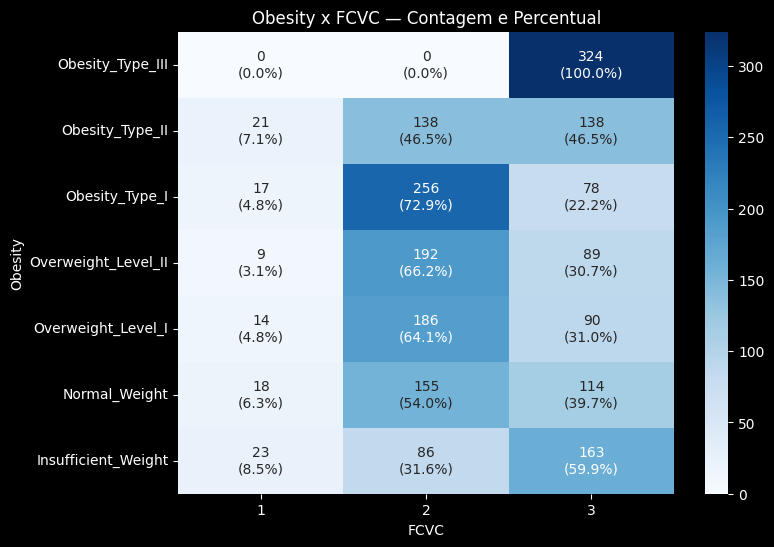

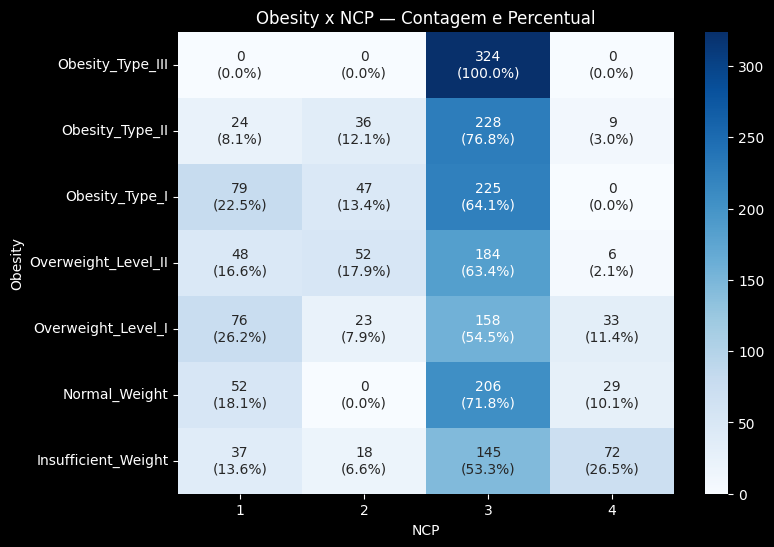

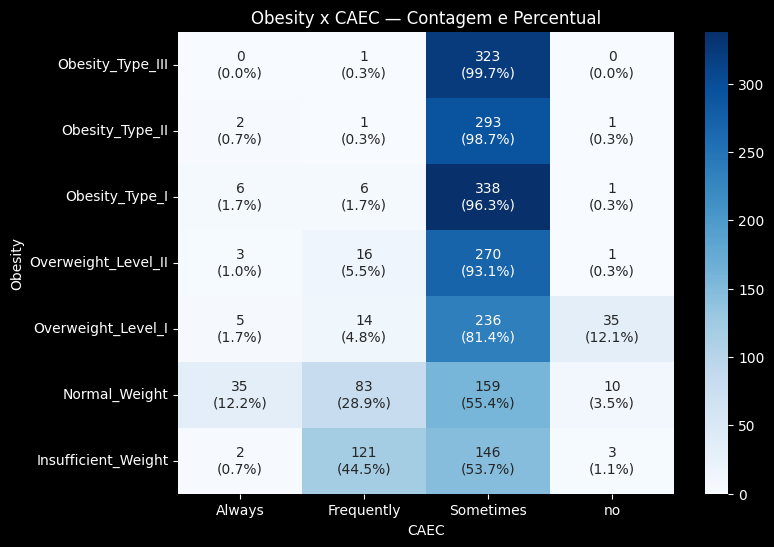

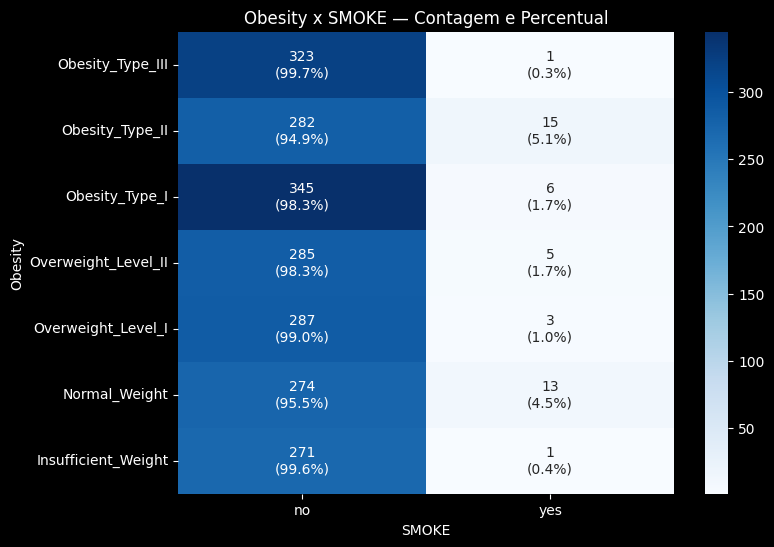

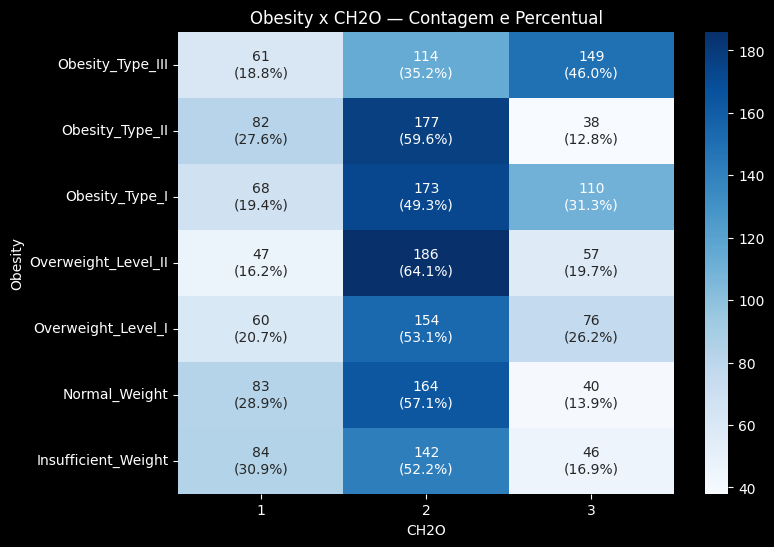

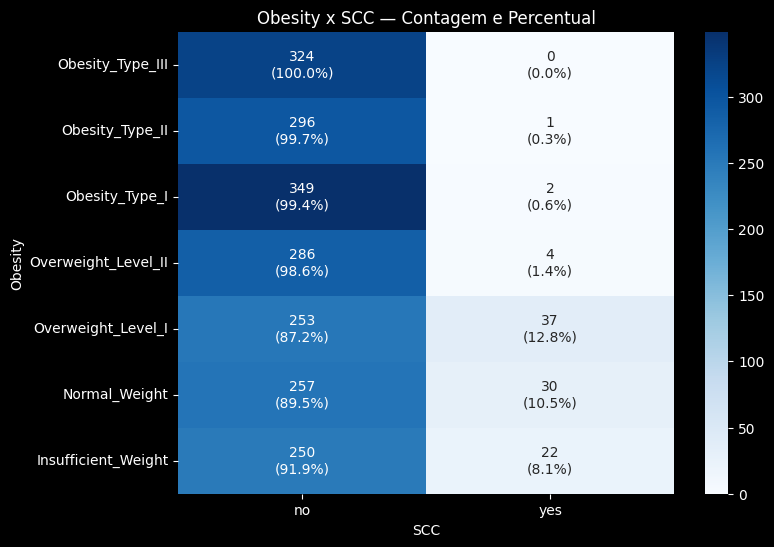

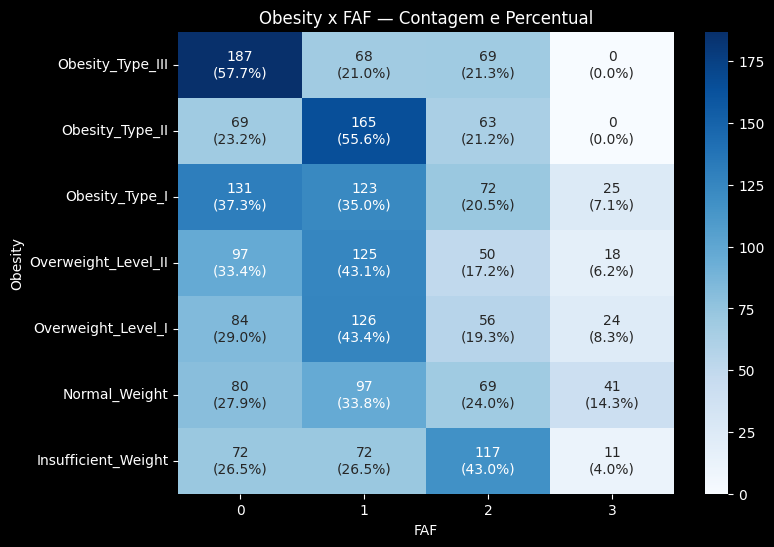

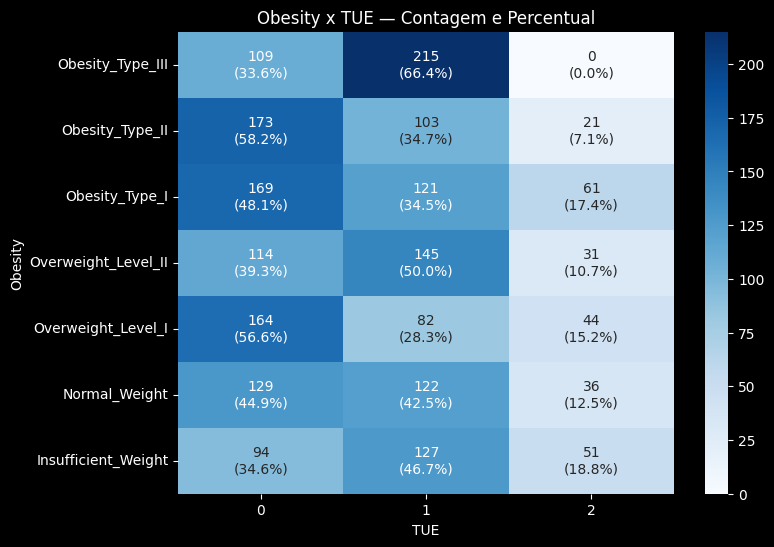

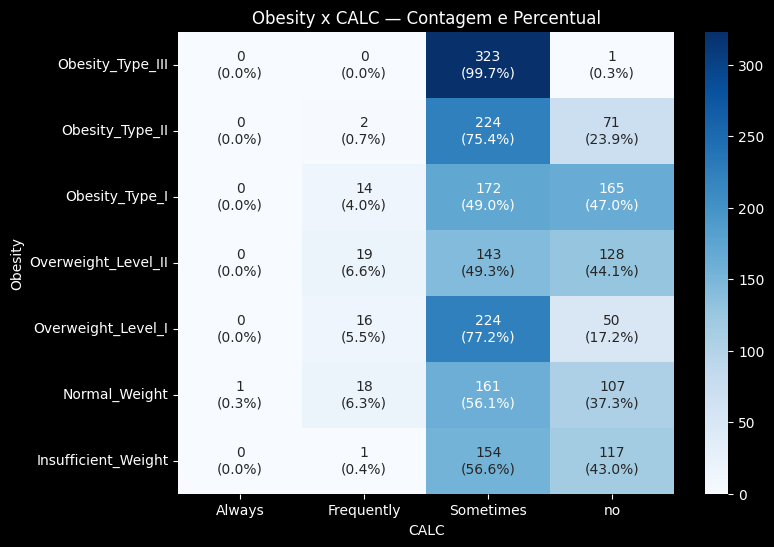

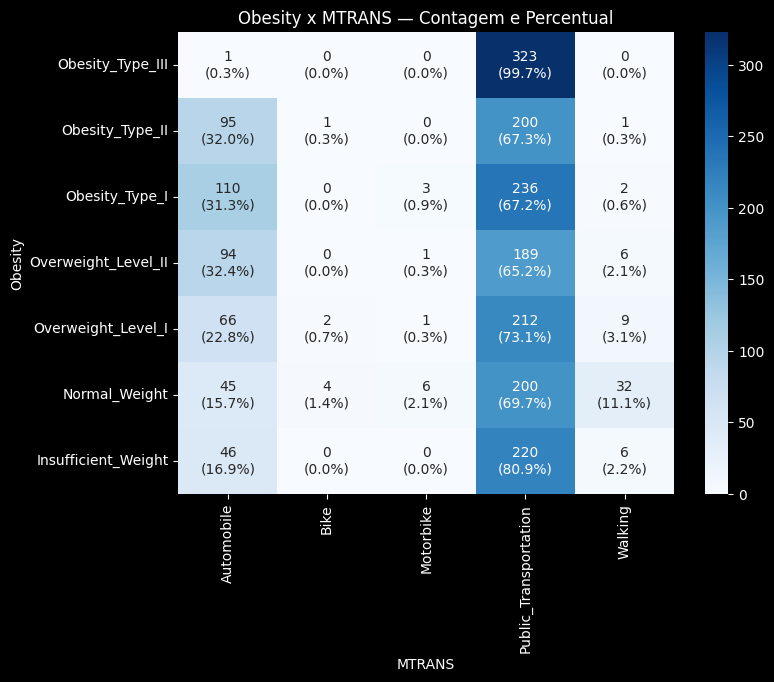

In [7]:
# ==================================================
# DISTRIBUIÇÃO DAS VARIÁVEIS CATEGÓRICAS E NUMÉRICAS DISCRETAS POR NÍVEL DE OBESIDADE
# ==================================================
colunas_heatmaps = df.columns.drop(['Obesity', 'Age', 'Height', 'Weight'])

ordem_obesity = [
    'Obesity_Type_III',
    'Obesity_Type_II',
    'Obesity_Type_I',
    'Overweight_Level_II',
    'Overweight_Level_I',
    'Normal_Weight',
    'Insufficient_Weight'
]

for col in colunas_heatmaps:

    tabela_cont = pd.crosstab(df[col], df['Obesity'])
    tabela_cont = tabela_cont[ordem_obesity].T

    tabela_perc = tabela_cont.div(tabela_cont.sum(axis=1), axis=0) * 100

    anotacoes = tabela_cont.astype(str) + "\n(" + tabela_perc.round(1).astype(str) + "%)"

    plt.figure(figsize=(8,6))
    sns.heatmap(
        tabela_cont,
        annot=anotacoes,
        fmt='',
        cmap='Blues'
    )

    plt.title(f'Obesity x {col} — Contagem e Percentual')
    plt.xlabel(col)
    plt.ylabel('Obesity')
    plt.show()

#### 3.7. Matriz de Correlação
Da mesma forma, a matriz de correlação ajuda a detectar relações fortes, fracas ou redundantes entre os atributos, além de evidenciar variáveis que podem não contribuir de forma significativa para a predição.

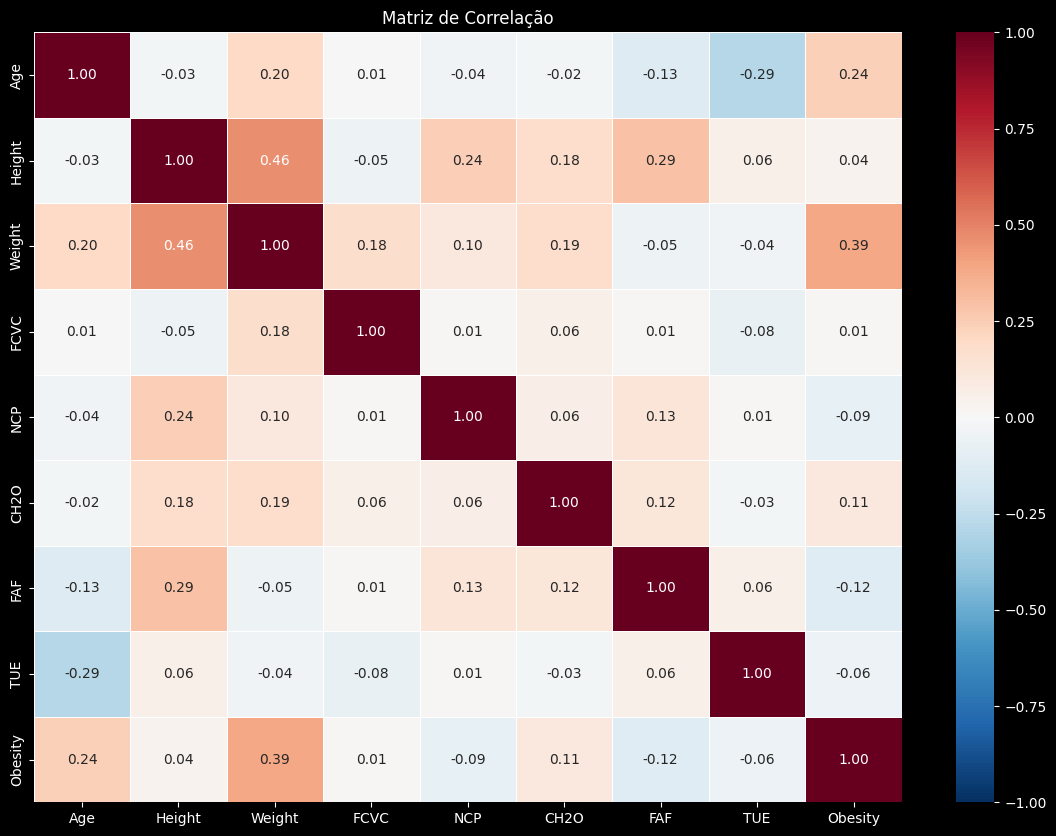

In [8]:
# ==================================================
# MATRIZ DE CORRELAÇÃO
# ==================================================
df_corr = df.copy()

df_corr['Obesity'] = LabelEncoder().fit_transform(df_corr['Obesity'])

corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(14,10))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title('Matriz de Correlação')
plt.show()

#### 3.8. Correlação com a Variável Target

In [9]:
# ==================================================
# CORRELAÇÃO COM A VARIÁVEL TARGET
# ==================================================
display(
    corr['Obesity']
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={
        'index': 'Variável',
        'Obesity': 'Correlação'
    })
    .style.hide(axis='index')
)

Variável,Correlação
Obesity,1.000000
Weight,0.387643
Age,0.236170
CH2O,0.108420
Height,0.038986
FCVC,0.012068
TUE,-0.059050
NCP,-0.085367
FAF,-0.120710


### 4. Feature Engineering
Durante a análise exploratória dos dados, observa-se que o conjunto apresenta desbalanceamento entre as classes de obesidade, com algumas categorias possuindo maior representatividade do que outras. Além disso, os gráficos exploratórios e matrizes de correlação evidenciam que determinadas variáveis possuem maior capacidade preditiva para os níveis de obesidade, especialmente aquelas relacionadas às medidas corporais.

Diante disso, o processo de feature engineering foi estruturado em dois cenários distintos, alinhados ao objetivo central do projeto:

1. um cenário utilizando exclusivamente variáveis comportamentais e de estilo de vida;
2. um cenário incluindo também medidas corporais, como peso e altura.

No primeiro cenário, foram selecionadas apenas variáveis relacionadas a hábitos alimentares, frequência de atividade física, consumo de água, uso de dispositivos eletrônicos, consumo de álcool, tabagismo e padrões comportamentais. O objetivo dessa abordagem é avaliar até que ponto informações de fácil coleta conseguem prever os níveis de obesidade sem depender diretamente de características antropométricas.

Já no segundo cenário, foram adicionadas variáveis corporais tradicionalmente associadas ao diagnóstico de obesidade, permitindo analisar o impacto dessas informações no desempenho dos modelos de Machine Learning.

#### 4.1. Definição das Features

In [10]:
# ==================================================
# CENÁRIO 01: FEATURES COMPORTAMENTAIS
# ==================================================
features_comportamentais = [
    'family_history', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS'
    ]

# ==================================================
# CENÁRIO 02: FEATURES COMPORTAMENTAIS + MEDIDAS CORPORAIS
# ==================================================
features_completo = [
    'family_history', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'Age', 'Height', 'Weight'
    ]

# ==================================================
# FEATURES CATEGÓRICAS UTILIZADAS EM AMBOS OS CENÁRIOS
# ==================================================
features_categoricas = [
    'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS'
    ]

#### 4.2. Preparação dos Dados

In [11]:
def preparar_dados(df, features):

    # ==================================================
    # SEPARAÇÃO ENTRE FEATURES E TARGET
    # ==================================================
    X = df[features]
    y = df['Obesity']

    # ==================================================
    # DIVISÃO ENTRE TREINO E TESTE
    # ==================================================
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )

    # ==================================================
    # ENCODER DA VARIÁVEL TARGET
    # ==================================================
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_test = le.transform(y_test)

    # ==================================================
    # PRÉ-PROCESSAMENTO DAS FEATURES
    # ==================================================
    preprocessamento = ColumnTransformer(
        transformers=[
            (
                'cat',
                OneHotEncoder(handle_unknown='ignore'),
                features_categoricas
            )
        ],
        remainder='passthrough'
    )

    # ==================================================
    # RETORNO DOS DADOS PROCESSADOS
    # ==================================================
    return(
        X_train,
        X_test,
        y_train,
        y_test,
        preprocessamento
    )

### 5. Machine Learning
#### 5.1. Definição dos Modelos de Machine Learning
Para a etapa de modelagem, foram selecionados os algoritmos RANDOM FOREST e XGBOOST, ambos amplamente utilizados em problemas de classificação supervisionada devido à sua robustez, capacidade preditiva e bom desempenho em bases de dados tabulares.

O Random Forest foi escolhido por ser um modelo baseado em múltiplas árvores de decisão, capaz de reduzir problemas de overfitting e lidar bem com relações não lineares entre as variáveis. Além disso, apresenta boa interpretabilidade e costuma gerar resultados consistentes mesmo com pouco ajuste de hiperparâmetros.

Já o XGBoost foi selecionado por ser um dos algoritmos de boosting mais eficientes e utilizados em competições e aplicações reais de Machine Learning. Seu funcionamento baseado em aprendizado sequencial permite corrigir erros das árvores anteriores, frequentemente resultando em maior capacidade preditiva e melhor desempenho em tarefas multiclasses.

A utilização dos dois modelos permite comparar diferentes abordagens de aprendizado baseadas em árvores, analisando tanto desempenho quanto capacidade de generalização nos dois cenários propostos pelo projeto.

In [12]:
# ==================================================
# DEFINIÇÃO DOS MODELOS DE MACHINE LEARNING
# ==================================================

modelos = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    'XGBoost': xgb.XGBClassifier(
        random_state=42
    )
}

# ==================================================
# FUNÇÃO DE EXECUÇÃO DOS MODELOS
# ==================================================
def executar_modelos(
    X_train,
    X_test,
    y_train,
    y_test,
    preprocessamento
):

    # ==================================================
    # DICIONÁRIOS DE RESULTADOS E PIPELINES
    # ==================================================
    resultados = {}
    pipelines = {}

    # ==================================================
    # TREINAMENTO E AVALIAÇÃO DOS MODELOS
    # ==================================================
    for nome, modelo in modelos.items():

        pipeline = Pipeline([
            ('preprocessor', preprocessamento),
            ('classifier', modelo)
        ])

        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)

        acc = accuracy_score(
            y_test,
            y_pred
        )
        resultados[nome] = acc
        pipelines[nome] = pipeline

    return resultados, pipelines

#### 5.2. Execução dos Modelos de Machine Learning

In [13]:
# ==================================================
# CENÁRIO 01: FEATURES COMPORTAMENTAIS
# ==================================================
X_train, X_test, y_train, y_test, preprocessamento = preparar_dados(
    df,
    features_comportamentais
)

resultados_comportamentais, pipelines_comportamentais = executar_modelos(
    X_train,
    X_test,
    y_train,
    y_test,
    preprocessamento
)

# ==================================================
# CENÁRIO 02: FEATURES COMPORTAMENTAIS + MEDIDAS CORPORAIS
# ==================================================
X_train, X_test, y_train, y_test, preprocessamento = preparar_dados(
    df,
    features_completo
)

resultados_completo, pipelines_completo = executar_modelos(
    X_train,
    X_test,
    y_train,
    y_test,
    preprocessamento
)

#### 5.3. Avaliação dos Modelos de Machine Learning (Acurácia)
Para avaliar o desempenho dos modelos, utilizou-se a acurácia como principal métrica de comparação. Essa métrica representa a proporção de previsões corretas realizadas pelo modelo em relação ao total de amostras avaliadas.
Os resultados obtidos evidenciam um ganho significativo de desempenho quando informações antropométricas são incorporadas aos modelos.
A partir dessa comparação, a acurácia foi utilizada como critério principal para identificar o modelo com melhor desempenho e definir qual abordagem apresenta maior potencial para continuidade das análises.

In [14]:
# ==================================================
# CENÁRIO 01: FEATURES COMPORTAMENTAIS
# ==================================================
print('\n========================================================')
print('CENÁRIO 01 — FEATURES COMPORTAMENTAIS')
print('========================================================')

for nome, acc in sorted(
    resultados_comportamentais.items(),
    key=lambda x: x[1],
    reverse=True
):

    print(f'{nome}: {acc:.2%}')

# ==================================================
# CENÁRIO 02: FEATURES COMPORTAMENTAIS + MEDIDAS CORPORAIS
# ==================================================
print('\n========================================================')
print('CENÁRIO 02 — FEATURES COMPORTAMENTAIS + MEDIDAS CORPORAIS')
print('========================================================')

for nome, acc in sorted(
    resultados_completo.items(),
    key=lambda x: x[1],
    reverse=True
):

    print(f'{nome}: {acc:.2%}')


CENÁRIO 01 — FEATURES COMPORTAMENTAIS
XGBoost: 72.10%
Random Forest: 71.39%

CENÁRIO 02 — FEATURES COMPORTAMENTAIS + MEDIDAS CORPORAIS
XGBoost: 96.22%
Random Forest: 92.91%


#### 5.4. Escolha do Modelo e Métricas de Avaliação
Após a comparação entre os modelos Random Forest e XGBoost nos dois cenários propostos, o modelo XGBoost aplicado ao cenário 02 — contendo variáveis comportamentais e medidas corporais — apresentou o melhor desempenho geral em termos de acurácia.

Os resultados confirmam que a inclusão de variáveis antropométricas, como peso e altura, aumenta significativamente a capacidade preditiva do modelo, uma vez que essas características possuem forte relação com os níveis de obesidade. Nesse contexto, o XGBoost destacou-se por sua maior eficiência em identificar padrões complexos e relações não lineares entre as variáveis.

Dessa forma, o XGBoost no cenário 02 foi definido como modelo final do projeto, sendo utilizado para análises complementares, interpretação das variáveis mais relevantes e avaliação detalhada das métricas de classificação.

In [15]:
# ==================================================
# CENÁRIO 02 - FEATURES COMPORTAMENTAIS + MEDIDAS CORPORAIS | MODELO XGBOOST
# ==================================================
ordem_classes = [
    'Obesity_Type_III',
    'Obesity_Type_II',
    'Obesity_Type_I',
    'Overweight_Level_II',
    'Overweight_Level_I',
    'Normal_Weight',
    'Insufficient_Weight'
]

le = LabelEncoder()
le.fit(df['Obesity'])

labels_ordenados = le.transform(ordem_classes)

pipeline_xgb = pipelines_completo['XGBoost']

y_pred = pipeline_xgb.predict(X_test)


print('\n==========================================================================')
print('CENÁRIO 02 — FEATURES COMPORTAMENTAIS + MEDIDAS CORPORAIS | MODELO XGBOOST')
print('==========================================================================')
print(
    classification_report(
        y_test,
        y_pred,
        labels=labels_ordenados,
        target_names=ordem_classes
    )
)


CENÁRIO 02 — FEATURES COMPORTAMENTAIS + MEDIDAS CORPORAIS | MODELO XGBOOST
                     precision    recall  f1-score   support

   Obesity_Type_III       0.98      1.00      0.99        63
    Obesity_Type_II       1.00      0.98      0.99        58
     Obesity_Type_I       0.99      0.97      0.98        78
Overweight_Level_II       1.00      0.98      0.99        50
 Overweight_Level_I       0.88      0.95      0.91        56
      Normal_Weight       0.95      0.85      0.90        62
Insufficient_Weight       0.93      1.00      0.97        56

           accuracy                           0.96       423
          macro avg       0.96      0.96      0.96       423
       weighted avg       0.96      0.96      0.96       423



#### 5.5. Importância das Features
A análise de importância das features permite identificar quais variáveis exercem maior influência nas decisões do modelo XGBoost durante a predição dos níveis de obesidade. Diferentemente da análise de correlação, que avalia relações estatísticas individuais entre variáveis, a importância das features considera o comportamento do modelo como um todo, incluindo interações complexas e relações não lineares entre os atributos.

Os resultados demonstraram que variáveis corporais, especialmente peso (*Weight*) e altura (*Height*), possuem forte impacto preditivo, reforçando sua relação direta com os níveis de obesidade. Entretanto, variáveis comportamentais também apresentaram relevância significativa, como hábitos alimentares, consumo de álcool, frequência de atividade física e padrões de transporte.

Esses resultados indicam que, embora as medidas corporais aumentem substancialmente a capacidade preditiva do modelo, fatores relacionados ao estilo de vida também contribuem de forma importante para a identificação dos diferentes níveis de obesidade. Dessa forma, a análise das importâncias das features complementa a interpretação do modelo e ajuda a compreender quais características mais influenciam suas previsões.

In [16]:
# ==================================================
# CENÁRIO 02 - FEATURES COMPORTAMENTAIS + MEDIDAS CORPORAIS | MODELO XGBOOST
# ==================================================

pipeline_xgb = pipelines_completo['XGBoost']

nomes_features = (
    pipeline_xgb.named_steps['preprocessor']
    .get_feature_names_out()
)

importancias = (
    pipeline_xgb.named_steps['classifier']
    .feature_importances_
)

importancias_df = pd.DataFrame({
    'Feature': nomes_features,
    'Importância': importancias
})

importancias_df['Feature'] = (
    importancias_df['Feature']
    .str.replace('cat__', '', regex=False)
    .str.replace('remainder__', '', regex=False)
    .str.split('_')
    .str[0]
)

importancias_df = (
    importancias_df
    .groupby('Feature')['Importância']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .style.hide(axis='index')
)

display(importancias_df)

Feature,Importância
CALC,0.181466
Weight,0.166408
MTRANS,0.121054
CAEC,0.111193
Height,0.073708
FCVC,0.069663
FAVC,0.068220
SMOKE,0.044567
Age,0.042457
NCP,0.036633


### 6. Armazenamento do Modelo Treinado
Após a etapa de treinamento e avaliação dos modelos, o pipeline final baseado em XGBoost foi armazenado utilizando a biblioteca *Joblib*. O armazenamento do modelo permite reutilizar toda a estrutura treinada sem a necessidade de executar novamente as etapas de pré-processamento, codificação das variáveis categóricas e treinamento do algoritmo.

O arquivo salvo contém não apenas o modelo XGBoost já ajustado, mas também todo o pipeline de transformação dos dados, incluindo o *OneHotEncoder* e o *ColumnTransformer*. Dessa forma, novos dados podem ser submetidos diretamente ao modelo mantendo exatamente o mesmo padrão de tratamento utilizado durante o treinamento.

Essa abordagem facilita a integração do modelo com aplicações externas, como o formulário desenvolvido em Streamlit, permitindo que usuários realizem predições em tempo real a partir do preenchimento de informações no sistema. Além disso, o armazenamento do pipeline garante maior portabilidade, reprodutibilidade e praticidade na implantação do projeto.

In [17]:
# ==================================================
# CENÁRIO 02 - FEATURES COMPORTAMENTAIS + MEDIDAS CORPORAIS | MODELO XGBOOST
# ==================================================
pipeline_xgb = pipelines_completo['XGBoost']

# ==================================================
# SALVAR O MODELO TREINADO
# ==================================================
joblib.dump(
    pipeline_xgb,
    'modelo_obesidade.pkl'
)

['modelo_obesidade.pkl']